In [5]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

cwd = Path.cwd().resolve()
repo_root = cwd.parent.parent
sys.path.insert(0, str(repo_root / 'src'))

from paper.style_utils import set_paper_style
set_paper_style()

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%config InlineBackend.figure_format = 'retina'


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# RMSD trajectories (single run)

This notebook plots a single RMSD trajectory for WT, D2M, and Y0A from COLVAR files.


In [ ]:
from common.colvar_utils import load_colvar, read_colvar_header_names
from common.consts import res_colors

data_root = repo_root / "data"
traj_root = data_root / "traj"

mutants = ["WT", "T5R", "Y9A"]
run_index = "001"

def resolve_colvar_path(mutant: str) -> Path:
    run_dir = data_root / mutant / "output" / f"run_{run_index}"
    run_path = run_dir / f"COLVAR_{run_index}"
    print(run_path)
    if run_path.exists():
        return run_path

    traj_dir = traj_root / mutant
    for name in ["COLVAR_CV_F", "COLVAR_CV_UF"]:
        candidate = traj_dir / name
        if candidate.exists():
            return candidate

    for base in [run_dir, traj_dir]:
        if base.is_dir():
            for candidate in sorted(base.glob("COLVAR*")):
                return candidate

    raise FileNotFoundError(f"No COLVAR found for {mutant}")

def pick_rmsd_column(path: Path) -> str:
    names = read_colvar_header_names(path)
    for candidate in ["rmsd_ca", "rmsd"]:
        if candidate in names:
            return candidate
    raise ValueError(f"No RMSD column found in {path}")

traj_data = {}
for mutant in mutants:
    colvar_path = resolve_colvar_path(mutant)
    rmsd_col = pick_rmsd_column(colvar_path)
    usecols = ["time", rmsd_col]
    df = load_colvar(colvar_path, usecols=usecols, nrows=None)
    df = df.rename(columns={rmsd_col: "rmsd"})
    traj_data[mutant] = df

traj_data


/rg/mendels_prj/alexander.z/protein-toolkit/data/WT/output/run_000/COLVAR_000
/rg/mendels_prj/alexander.z/protein-toolkit/data/T5R/output/run_000/COLVAR_000
/rg/mendels_prj/alexander.z/protein-toolkit/data/Y9A/output/run_000/COLVAR_000


{'WT':         time      rmsd
 0        0.0  0.062236
 1        1.0  0.083178
 2        2.0  0.079589
 3        3.0  0.070479
 4        4.0  0.090658
 ...      ...       ...
 1996  1996.0  0.466851
 1997  1997.0  0.442649
 1998  1998.0  0.441736
 1999  1999.0  0.450490
 2000  2000.0  0.455945
 
 [2001 rows x 2 columns],
 'T5R':         time      rmsd
 0        0.0  0.021594
 1        1.0  0.036605
 2        2.0  0.035644
 3        3.0  0.046630
 4        4.0  0.065843
 ...      ...       ...
 1996  1996.0  0.086125
 1997  1997.0  0.084216
 1998  1998.0  0.079625
 1999  1999.0  0.096258
 2000  2000.0  0.095591
 
 [2001 rows x 2 columns],
 'Y9A':         time      rmsd
 0        0.0  0.226059
 1        1.0  0.224849
 2        2.0  0.219422
 3        3.0  0.227037
 4        4.0  0.219023
 ...      ...       ...
 1996  1996.0  0.374503
 1997  1997.0  0.380299
 1998  1998.0  0.404512
 1999  1999.0  0.395670
 2000  2000.0  0.411173
 
 [2001 rows x 2 columns]}

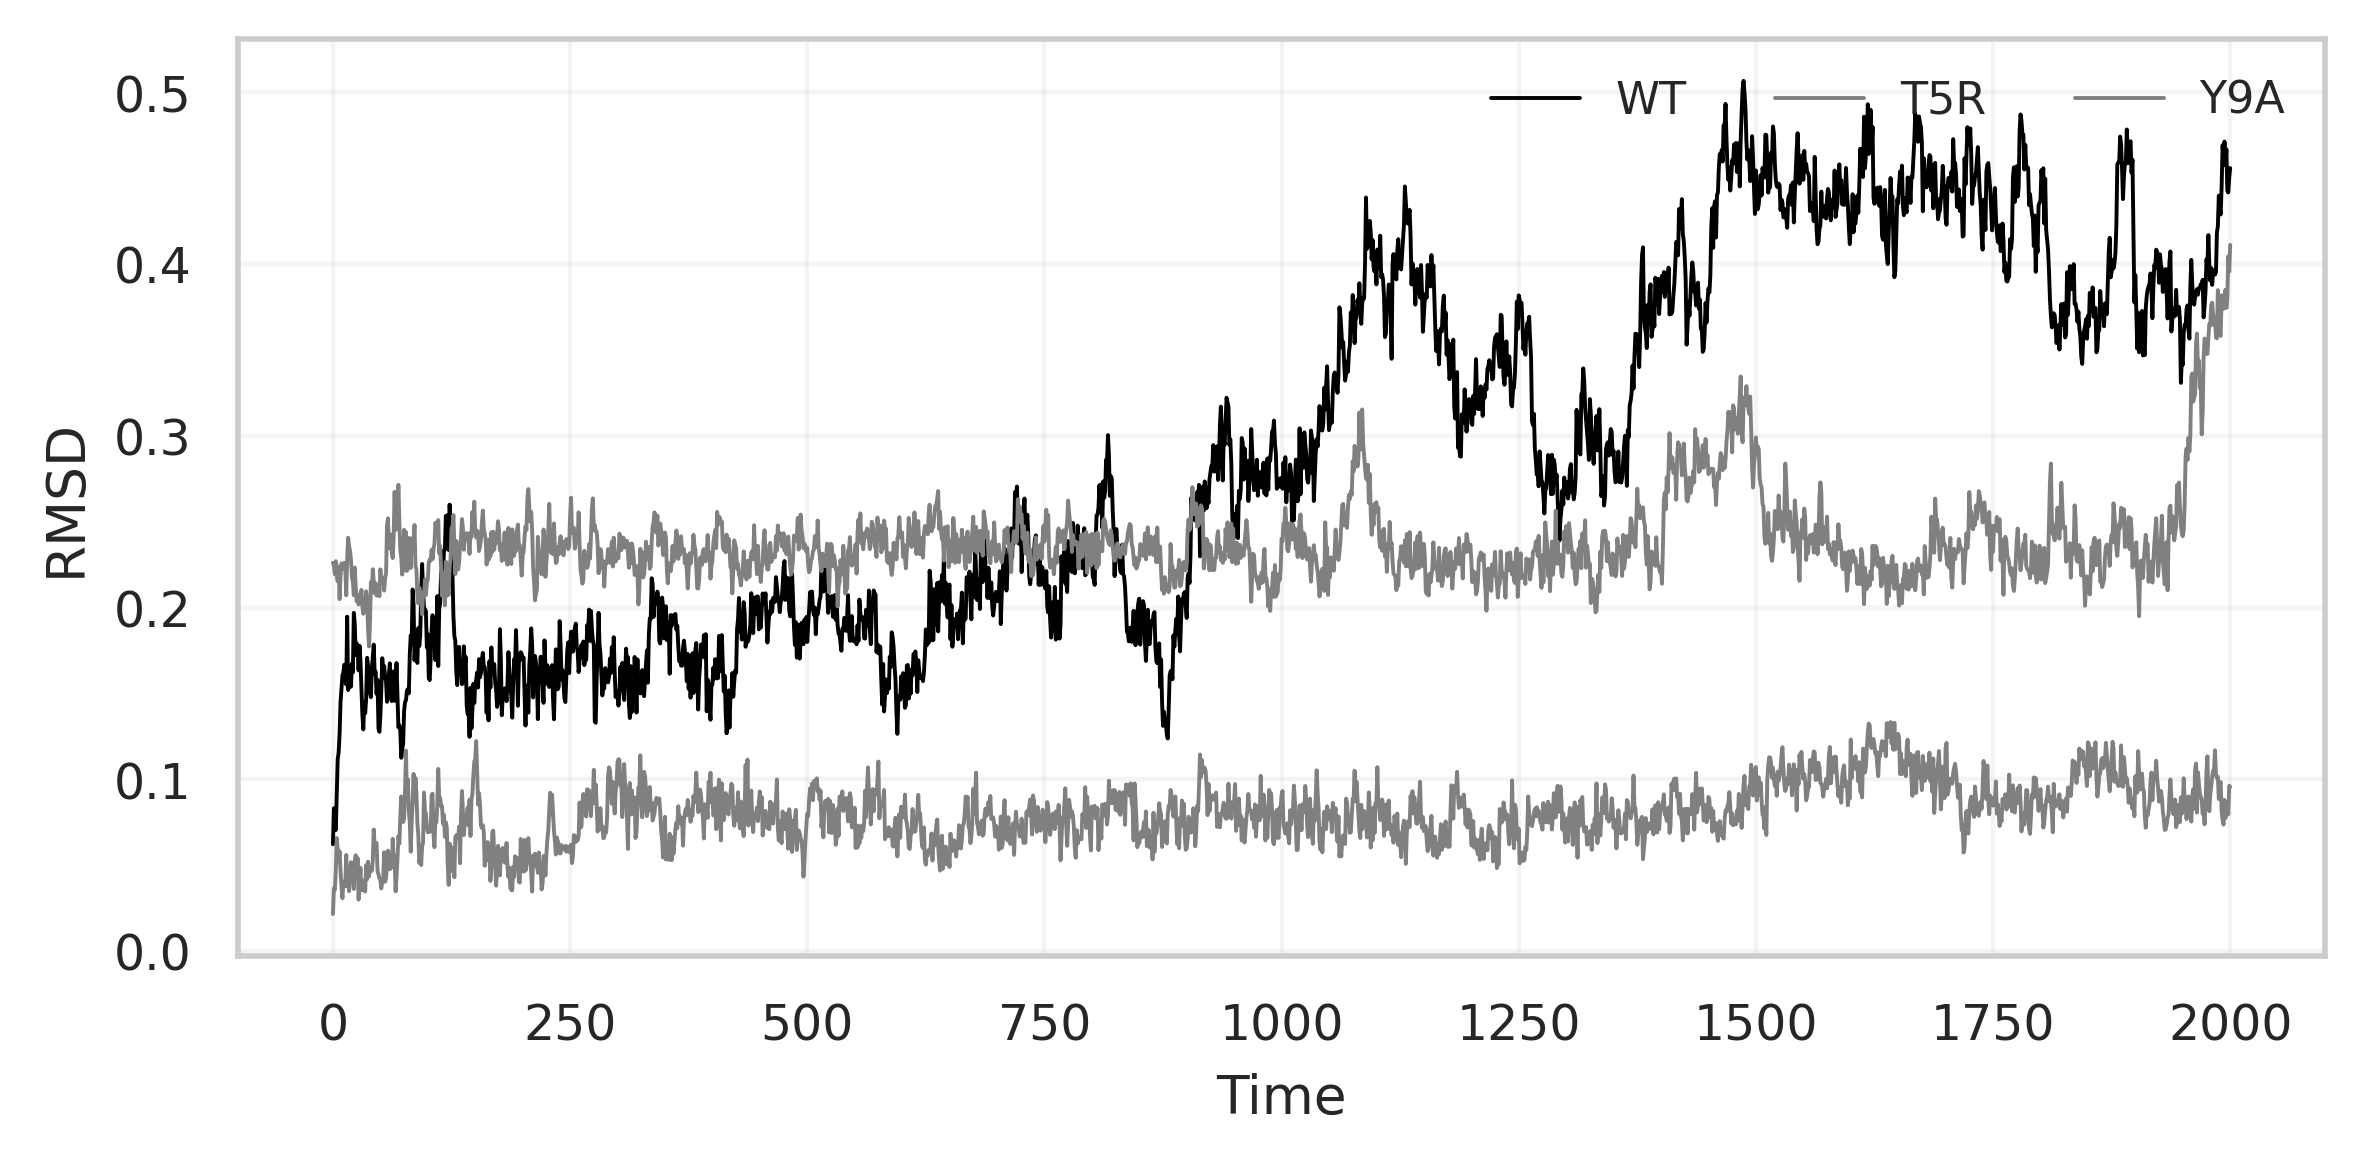

In [7]:
stride = 1  # increase to thin the trajectory (e.g., 10)
max_points = 50000

color_map = {
    "WT": "black",
    "D2M": res_colors.get(2, "orange"),
    "Y0A": res_colors.get(0, "red"),
}

fig, ax = plt.subplots(figsize=(6, 3), dpi=200)
for mutant, df in traj_data.items():
    plot_df = df.iloc[::stride][:max_points].copy()
    ax.plot(
        plot_df["time"],
        plot_df["rmsd"],
        lw=0.7,
        color=color_map.get(mutant, "gray"),
        label=mutant,
    )

ax.set_xlabel("Time")
ax.set_ylabel("RMSD")
ax.grid(alpha=0.2)
ax.legend(frameon=False, fontsize=8, ncol=3, loc="upper right")
plt.tight_layout()
